<a href="https://colab.research.google.com/github/dang710206/btap-AI---week-2/blob/main/bt13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.6 MB/s eta 0:00:00


Mức chiết khấu đề xuất: 16.78 %


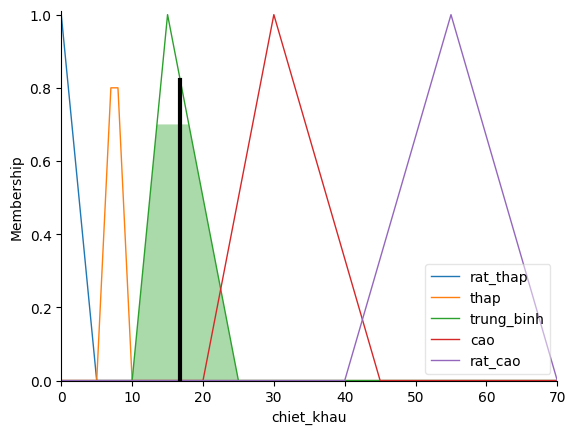

In [3]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

nhu_cau_san_pham = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau_san_pham')
ap_luc_doi_thu = ctrl.Antecedent(np.arange(0, 101, 1), 'ap_luc_doi_thu')
uy_tin_cua_hang = ctrl.Antecedent(np.arange(0, 101, 1), 'uy_tin_cua_hang')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_loi_nhuan')
nhu_cau_mua = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau_mua')

chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

nhu_cau_san_pham['thap'] = fuzz.trimf(nhu_cau_san_pham.universe, [0, 0, 40])
nhu_cau_san_pham['trung_binh'] = fuzz.trimf(nhu_cau_san_pham.universe, [30, 50, 70])
nhu_cau_san_pham['cao'] = fuzz.trimf(nhu_cau_san_pham.universe, [60, 100, 100])

ap_luc_doi_thu['thap'] = fuzz.trimf(ap_luc_doi_thu.universe, [0, 0, 35])
ap_luc_doi_thu['trung_binh'] = fuzz.trimf(ap_luc_doi_thu.universe, [25, 50, 75])
ap_luc_doi_thu['cao'] = fuzz.trimf(ap_luc_doi_thu.universe, [65, 100, 100])

uy_tin_cua_hang['thap'] = fuzz.trimf(uy_tin_cua_hang.universe, [0, 0, 40])
uy_tin_cua_hang['trung_binh'] = fuzz.trimf(uy_tin_cua_hang.universe, [30, 50, 70])
uy_tin_cua_hang['cao'] = fuzz.trimf(uy_tin_cua_hang.universe, [60, 100, 100])

bien_loi_nhuan['thap'] = fuzz.trimf(bien_loi_nhuan.universe, [0, 0, 35])
bien_loi_nhuan['trung_binh'] = fuzz.trimf(bien_loi_nhuan.universe, [25, 50, 75])
bien_loi_nhuan['cao'] = fuzz.trimf(bien_loi_nhuan.universe, [65, 100, 100])

nhu_cau_mua['thap'] = fuzz.trimf(nhu_cau_mua.universe, [0, 0, 30])
nhu_cau_mua['trung_binh'] = fuzz.trimf(nhu_cau_mua.universe, [20, 50, 80])
nhu_cau_mua['cao'] = fuzz.trimf(nhu_cau_mua.universe, [60, 100, 100])

chiet_khau['rat_thap'] = fuzz.trimf(chiet_khau.universe, [0, 0, 5])
chiet_khau['thap'] = fuzz.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [10, 15, 25])
chiet_khau['cao'] = fuzz.trimf(chiet_khau.universe, [20, 30, 45])
chiet_khau['rat_cao'] = fuzz.trimf(chiet_khau.universe, [40, 55, 70])

rule1 = ctrl.Rule(nhu_cau_san_pham['cao'] & ap_luc_doi_thu['thap'] & bien_loi_nhuan['thap'], chiet_khau['rat_thap'])
rule2 = ctrl.Rule(nhu_cau_san_pham['thap'] & ap_luc_doi_thu['cao'] & bien_loi_nhuan['cao'], chiet_khau['cao'])
rule3 = ctrl.Rule(uy_tin_cua_hang['cao'] & bien_loi_nhuan['trung_binh'] & nhu_cau_mua['cao'], chiet_khau['trung_binh'])
rule4 = ctrl.Rule(ap_luc_doi_thu['cao'] & nhu_cau_mua['cao'] & bien_loi_nhuan['cao'], chiet_khau['rat_cao'])
rule5 = ctrl.Rule(uy_tin_cua_hang['thap'] & nhu_cau_san_pham['trung_binh'] & bien_loi_nhuan['thap'], chiet_khau['trung_binh'])
rule6 = ctrl.Rule(nhu_cau_san_pham['cao'] & nhu_cau_mua['thap'] & ap_luc_doi_thu['thap'], chiet_khau['rat_thap'])
rule7 = ctrl.Rule(bien_loi_nhuan['cao'] & ap_luc_doi_thu['trung_binh'] & nhu_cau_mua['trung_binh'], chiet_khau['trung_binh'])
rule_default = ctrl.Rule(nhu_cau_san_pham['cao'] & nhu_cau_mua['cao'], chiet_khau['trung_binh'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule_default]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['nhu_cau_san_pham'] = 88
discount_sim.input['ap_luc_doi_thu'] = 55
discount_sim.input['uy_tin_cua_hang'] = 52
discount_sim.input['bien_loi_nhuan'] = 78
discount_sim.input['nhu_cau_mua'] = 92

discount_sim.compute()

if 'chiet_khau' in discount_sim.output:
    print("Mức chiết khấu đề xuất:", round(discount_sim.output['chiet_khau'], 2), "%")
else:
    print("Không tính được kết quả. Hãy kiểm tra lại rules.")

chiet_khau.view(sim=discount_sim)
plt.show()